<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# III. Materiais elásticos
## Lei de Hooke. Parte II
## Problema 6 <a name="PIII76"></a>

Considere a placa plana da Figura com 100 mm de largura e 240 mm de comprimento sujeita a tensões de corte $\tau_{xy}$ de valor desconhecido e tensões normais $\sigma_{xx}$ e $\sigma_{yy}$ de valores 160 MPa e 60 MPa respectivamente. Considere que o material tem comportamento elástico e isotrópico, com $E = 70$  GPa e $\nu = 0,3$.

[a)](#A) Determine a gama de valores $\tau_{xy}$ para a qual a tensão tangencial máxima é igual ou inferior a 100 MPa.

Considere agora que $\tau_{xy}$ igual a 80 MPa.

[b)](#B) Calcule a variação de comprimento da diagonal representada na figura.

[c)](#C) Determine as extensões principais e o valor da distorção máxima.

[d)](#D) Determine as componentes normal e tangencial da tensão no plano vertical que passa pela diagonal representada na figura.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au07/Au07_P006_i1.jpg"
width="400" height="160">



## Resolução

#### a) Determine a gama de valores $\tau_{xy}$ para a qual a tensão tangencial máxima é igual ou inferior a 100 MPa.<a name="A"></a>

([enunciatum](#PIII76))

O estado de tensão no referencial $S_0(x,y,z)$ é dado pela seguinte representação matricial:

\begin{equation*}
\underline{\underline{\sigma}} = \sigma_{ij} =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{yx} & \sigma_{yy} & \tau_{yz} \\
\tau_{zx} & \tau_{zy} & \sigma_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
160 & \tau_{xy} & 0 \\
\tau_{yx} & 60 & 0 \\
0 & 0 & 0 \\
\end{bmatrix} \equiv
\begin{bmatrix}
160 & \tau_{xy} \\
\tau_{yx} & 60 \\
\end{bmatrix}\quad\mathrm{(MPa)}
\end{equation*}

Este estado de tensão corresponde a um estado plano para o qual: $\sigma_{zz} = \tau_{xz} = \tau_{yz} = 0$.

Para o estado plano de tensão a tensão de corte máxima vem:

\begin{equation*}
\tau_\mathrm{max} = \frac{\sigma_\mathrm{I} - \sigma_\mathrm{III}}{2} \leq 100 ~~\mathrm{MPa}
\end{equation*}

De onde se conclui,

\begin{equation*}
\sigma_\mathrm{I} \leq 200 ~~\mathrm{MPa}
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au07/Au07_P006_i2.jpg"
width="600" height="400">

Da análise do círculo de Mohr conclui-se:

\begin{equation*}
\begin{aligned}
\sigma_\mathrm{I} \equiv \sigma_\mathrm{max} = \sigma_\mathrm{med} + R \\
\sigma_\mathrm{II} \equiv \sigma_\mathrm{min} = \sigma_\mathrm{med} - R \\
\end{aligned}
\end{equation*}

em que $\sigma_\mathrm{med}$ é a amplitude média representando o centro do círculo de Mohr

\begin{equation*}
\sigma_\mathrm{med} = \frac{\sigma_{xx} + \sigma_{yy}}{2} \\
\end{equation*}

e o raio do círculo, $R$ vem:

\begin{equation*}
R = \sqrt{ \left( \frac{\sigma_{xx} - \sigma_{yy}}{2} \right)^2  + \tau_{xy}^2 }  \\
\end{equation*}

Pelo que resulta,

\begin{equation*}
\sigma_\mathrm{I} = \sigma_\mathrm{med} + R
= \frac{\sigma_{xx} + \sigma_{yy}}{2} +
\sqrt{ \left( \frac{\sigma_{xx} - \sigma_{yy}}{2} \right)^2  + \tau_{xy}^2 }
 \leq 200 \\
\end{equation*}

In [19]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
from sympy import symbols
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 18
rc('text', usetex=False)

# Dados, unidade : MPa
sxxP, syyP, tmax = 160, 60, 100

print('------------------------------')
print('H1: sigma zz = sigma III = 0 :')
print('------------------------------')
txy = symbols('txy')
ex1 = (sxxP + syyP)/2 + sy.sqrt( ((sxxP - syyP)/2)**2 + txy**2 ) - 2*tmax
tens1 = solve({ex1},txy)
print(tens1)
txyP = np.abs(tens1[0][0])
print(f'| Sxy(P) | = {txyP:.6f} (MPa)')

print('------------------------------')
print('H2: sigma zz = sigma II = 0 :')
print('------------------------------')
print('Esta hipótese não se verifica ')

------------------------------
H1: sigma zz = sigma III = 0 :
------------------------------
[(-74.8331477354788,), (74.8331477354788,)]
| Sxy(P) | = 74.833148 (MPa)
------------------------------
H2: sigma zz = sigma II = 0 :
------------------------------
Esta hipótese não se verifica 


#### b) Calcule a variação de comprimento da diagonal representada na figura.<a name="B"></a>

([enunciatum](#PIII76))

É possível mostrar que a deformação linear numa determinada direção, $\vec{n}$, definida pelos cosenos diretores $n_x,n_yn_z$ é dada pela seguinte expressão de transformação em relação às componentes da matriz de deformação em relação a um dado referencial:

\begin{equation*}
\varepsilon(\vec{n}) =
\varepsilon_{xx} n_x^2 + \varepsilon_{yy}n_y^2 + \varepsilon_{zz}n_z^2
+ \varepsilon_{xy}n_xn_y + \varepsilon_{yz}n_yn_z + \varepsilon_{xz}n_xn_z
\end{equation*}

Se a direção $\vec{n}$ dizer um determinado ângulo $\theta$ em relação ao eixo horizontal dos $xx$ então a lei de transformação pode ser dada por:

\begin{equation*}
\varepsilon(\theta) = \varepsilon_{xx}\cos^2\theta + \varepsilon_{yy}\sin^2\theta + \gamma_{xy}\sin\theta\cos\theta
\end{equation*}

Pelo que a variação em comprimento do segmento $AB$ pode ser obtida de acordo com a definição de deformação linear:

\begin{equation*}
\varepsilon(\theta) = \frac{\Delta L}{L}
= \frac{L_f - L}{L}
\Leftrightarrow
L_f = (1+\varepsilon)L
\end{equation*}

ou seja,

\begin{equation*}
\Delta L = (\varepsilon_{xx}\cos^2\theta + \varepsilon_{yy}\sin^2\theta +
\gamma_{xy}\sin\theta\cos\theta )L
\end{equation*}

In [20]:
def tt(s11,s22,s33,s23,s13,s12):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s23,s33]])

sxyP = 80 # unidade : MPa
szzP = sxzP = syzP = 0 # estado plano de tensão
mt0 = tt(sxxP,syyP,0,0,0,sxyP)
print('Estado de tensão :\n',mt0,' MPa')

E = 70*1e3 # unit: MPa
v = 0.3
G = E/2/(1+v)
lam = (E*v)/((1+v)*(1-2*v))
mu = G
print('Propriedades do material: ---------------')
print('     E (MPa) = ',E)
print('           v = ',v)
print(f'     G (MPa) = {G:.2f}')
print(f'lambda (MPa) = {lam:.2f}')
print(f'    mu (MPa) = {mu:.2f}')

def e11(sxx,syy,szz,E,v): return (sxx - v*(syy+szz))/E
def e22(sxx,syy,szz,E,v): return (syy - v*(sxx+szz))/E
def e33(sxx,syy,szz,E,v): return (szz - v*(sxx+syy))/E
def e23(syz,G): return (syz/G)/2
def e13(sxz,G): return (sxz/G)/2
def e12(sxy,G): return (sxy/G)/2

exxP = e11(sxxP,syyP,szzP,E,v)
eyyP = e22(sxxP,syyP,szzP,E,v)
ezzP = e33(sxxP,syyP,szzP,E,v)
eyzP = e23(syzP,G)
exzP = e13(sxzP,G)
exyP = e12(sxyP,G)

md0 = np.array([[exxP,exyP,exzP],[exyP,eyyP,eyzP],[exzP,eyzP,ezzP]])
np.set_printoptions(formatter={'float': '{: 0.3f}'.format})
print('Estado de deformação  = \n',md0*1e6,' micro-def')

print('-----------------------------------------------')
print('Versão 1:')
print('-----------------------------------------------')
# Dados, unidades: mm
Lx, Ly = 100, 240

abeta = np.arctan(Ly/Lx)
aalpha = np.arctan(Lx/Ly)
atheta = aalpha + np.pi/2
print(f'Ângulo beta = {np.rad2deg(abeta):.3f} deg')
print(f'Ângulo alpha = {np.rad2deg(aalpha):.3f} deg')
print(f'Ângulo theta = {np.rad2deg(atheta):.3f} deg')

def extensometro(e11,e22,g12,t):
    return e11*np.cos(t)**2 +  e22*np.sin(t)**2 + g12*np.sin(t)*np.cos(t)

epsdiag = extensometro(exxP,eyyP,2*exyP,-abeta)
print(f'ext diagonal (-beta) = {epsdiag*1e6:.4f} micro-def')

epsdiag2 = extensometro(exxP,eyyP,2*exyP,atheta)
print(f'ext diagonal (+theta)= {epsdiag2*1e6:.4f} micro-def')

LdiagI = np.sqrt(Lx**2 + Ly**2)
print(f'Comprimento inicial da diagonal = {LdiagI:.4f} mm')
LdiagF = (1+epsdiag)*LdiagI
print(f'Comprimento final da diagonal = {LdiagF:.4f} mm')
DLdiag1 = epsdiag*LdiagI
print(f'DL diagonal = {DLdiag1:.4e} mm | {DLdiag1*1e3:.3f} microns')


Estado de tensão :
 [[160  80   0]
 [ 80  60   0]
 [  0   0   0]]  MPa
Propriedades do material: ---------------
     E (MPa) =  70000.0
           v =  0.3
     G (MPa) = 26923.08
lambda (MPa) = 40384.62
    mu (MPa) = 26923.08
Estado de deformação  = 
 [[ 2028.571  1485.714  0.000]
 [ 1485.714  171.429  0.000]
 [ 0.000  0.000 -942.857]]  micro-def
-----------------------------------------------
Versão 1:
-----------------------------------------------
Ângulo beta = 67.380 deg
Ângulo alpha = 22.620 deg
Ângulo theta = 112.620 deg
ext diagonal (-beta) = -608.7912 micro-def
ext diagonal (+theta)= -608.7912 micro-def
Comprimento inicial da diagonal = 260.0000 mm
Comprimento final da diagonal = 259.8417 mm
DL diagonal = -1.5829e-01 mm | -158.286 microns


Por outro lado, pela lei de transformação de um tensor de segunda ordem, a transformação do tensor das deformações vem:

\begin{equation*}
[\varepsilon]_1 = [Q_{01}(\theta)]\,[\varepsilon]_0[Q_{01}(\theta)]^\mathrm{T}
\end{equation*}

Explicitamente,

\begin{equation*}
\begin{bmatrix}
\varepsilon_{x'x'} & \varepsilon_{x'y'} & \varepsilon_{x'z'}\\
\varepsilon_{y'y'} & \varepsilon_{y'y'} & \varepsilon_{y'z'}\\
\varepsilon_{z'y'} & \varepsilon_{z'y'} & \varepsilon_{z'z'}\\
\end{bmatrix} =
\begin{bmatrix}
\cos\theta & \sin\theta & 0\\
-\sin\theta  & \cos\theta & 0\\
0 & 0 & 1 \\
\end{bmatrix}
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz} \\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zx} & \varepsilon_{zy} & \varepsilon_{zz} \\
\end{bmatrix}
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta  & \cos\theta & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
\end{equation*}

Em relação ao esquema da figura (no formulário $\theta=\beta$),

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au07/Au07_P006_i3.jpg"
width="600" height="400">

onde,

\begin{equation*}
\Delta L = L_f - L
\quad\wedge\quad L_f = (1+\varepsilon_{x'x'})L
\end{equation*}

In [21]:
print('-----------------------------------------------')
print('Versão 2:')
print('-----------------------------------------------')
def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

mT = Q(-abeta,3)
# ou: mT = np.transpose(Q(theta,3))
print(' mT (-beta) = \n',mT)
np.set_printoptions(formatter={'float': '{: 0.5f}'.format})
md0diag = np.dot(mT,np.dot(md0,np.transpose(mT)))
print(' mat def diagonal = \n',md0diag*1e6,'micro-def')

ediag2  = md0diag[0,0]
print(f'ext diagonal = {ediag2*1e6:.4f} micro-def')
DLdiag2 = ediag2*LdiagI
print(f'DL diagonal = {DLdiag2:.4e} mm | {DLdiag2*1e3:.3f} microns')


-----------------------------------------------
Versão 2:
-----------------------------------------------
 mT (-beta) = 
 [[ 0.385 -0.923  0.000]
 [ 0.923  0.385  0.000]
 [ 0.000  0.000  1.000]]
 mat def diagonal = 
 [[-608.79121 -386.81319  0.00000]
 [-386.81319  2808.79121  0.00000]
 [ 0.00000  0.00000 -942.85714]] micro-def
ext diagonal = -608.7912 micro-def
DL diagonal = -1.5829e-01 mm | -158.286 microns


In [22]:
print('-----------------------------------------------')
print('Versão 3:')
print('-----------------------------------------------')
nx = np.cos(abeta)
ny = np.cos(abeta+np.pi/2)
nz = np.cos(np.pi/2)
nvec = np.array([nx,ny,nz])
print(f'versor n AB = {nvec} | norma: {np.sqrt(np.dot(nvec,nvec)):.2f}')

def epsn(exx,eyy,ezz,exy,eyz,exz,nx,ny,nz):
    return exx*nx**2 + eyy*ny**2 + ezz*nz**2 + exy*nx*ny + eyz*ny*nz + exz*nx*nz

ediag3 = epsn(exxP,eyyP,ezzP,2*exyP,2*eyzP,2*exzP,nx,ny,nz)
print(f'ext diagonal = {ediag3*1e6:.4f} micro-def')
print(f'Comprimento final da diagonal = {(1+ediag3)*LdiagI:.4f} mm')
DLdiag3 = ediag3*LdiagI
print(f'DL diagonal = {DLdiag3:.4e} mm | {DLdiag3*1e3:.3f} microns')

-----------------------------------------------
Versão 3:
-----------------------------------------------
versor n AB = [ 0.38462 -0.92308  0.00000] | norma: 1.00
ext diagonal = -608.7912 micro-def
Comprimento final da diagonal = 259.8417 mm
DL diagonal = -1.5829e-01 mm | -158.286 microns


#### c) Determine as extensões principais e o valor da distorção máxima.<a name="C"></a>

([enunciatum](#PIII76))

Para um dado tensor de deformações definido num ponto $P$ de um objeto, torna-se relevante saber determinar os valores extremos das extensões lineares e das distorções de corte, máximos e mínimas. Este problema é equivalente à determinação dos valores e vetores próprios de uma matriz.

As deformações principais e as direções principais resultam da análise do seguinte sistema de equações:

\begin{equation*}
\begin{aligned}
(\varepsilon_{xx} - \epsilon) n_x + \varepsilon_{xy} n_y + \varepsilon_{xz} n_z = 0 \\
\varepsilon_{yx} n_x + (\varepsilon_{yy} - \epsilon) n_y + \varepsilon_{yz} n_z = 0 \\
\varepsilon_{zx} n_x + \varepsilon_{zy} n_y + (\varepsilon_{zz} - \epsilon) n_z= 0 \\
\end{aligned}
\end{equation*}

Este sitema de equações é homogéneo em $n_x, n_y, n_z$. A existência de uma solução não-trivial impica que seja nulo o
seguinte determinante:

\begin{equation*}
\begin{vmatrix}
(\varepsilon_{xx} - \epsilon) & \varepsilon_{xy} & \varepsilon_{xz} \\
\varepsilon_{yx} & (\varepsilon_{yy} - \epsilon) &  \varepsilon_{yz} \\
\varepsilon_{zx} & \varepsilon_{zy} & (\varepsilon_{zz} - \epsilon) \\
\end{vmatrix} = 0
\end{equation*}

O desenvolvimento algébrico deste determinante conduz ao chamado polonímio ou equação caraterística:

\begin{equation*}
p(\epsilon) = \epsilon^3 - I_\mathrm{\epsilon}\epsilon^2 + II_\mathrm{\epsilon}\epsilon - III_\mathrm{\epsilon} =
\epsilon^3 - J_1 \epsilon^2 + J_2\epsilon - J_3  = 0
\end{equation*}

onde,

\begin{equation*}
\begin{aligned}
J_1 & = \mathrm{Tr}(\varepsilon_{ij}) = \varepsilon_{xx} + \varepsilon_{yy} + \varepsilon_{zz}\\
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
J_2 & = \frac{1}{2}\left[ \mathrm{Tr}(\varepsilon_{ij})^2 - \mathrm{Tr}(\varepsilon_{ij}^2) \right] =
\frac{1}{2}\left( \varepsilon_{ii}\varepsilon_{jj} - \varepsilon_{ij}\varepsilon_{ji} \right) \\
& =
\begin{vmatrix}
\varepsilon_{xx} & \varepsilon_{xy} \\
\varepsilon_{yx} & \varepsilon_{yy} \\
\end{vmatrix} +
\begin{vmatrix}
\varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zy} & \varepsilon_{zz} \\
\end{vmatrix} +
\begin{vmatrix}
\varepsilon_{xx} & \varepsilon_{xz} \\
\varepsilon_{zx} & \varepsilon_{zz} \\
\end{vmatrix}%
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
J_3 & = \mathrm{det}(\varepsilon_{ij}) = \begin{vmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz}\\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz}\\
\varepsilon_{zx} & \varepsilon_{zy} & \varepsilon_{zz}\\
\end{vmatrix}\\
\end{aligned}
\end{equation*}

De observar que os invariantes $J_2$ e $J_3$ são em função das componentes tensoriais de corte, $\varepsilon_{yz}, \varepsilon_{xz}, \varepsilon_{yx}$ e não as componentes de corte de engenharia $\gamma_{yz}, \gamma_{xz}, gamma_{yx}$.

Para um dado estado de deformação no ponto $P$, se a deformação ou extensão linear $\epsilon$ é um valor extremo numa direção $\vec{n}$, então esta é uma deformação principal no ponto $P$ e $\vec{n}$ é uma direção principal de deformação associada a $\epsilon$.

Para cada estado de deformação existem pelos menos três eixos principais, mutuamente perpendiculares entre si,  ou cúbica) e o máximo três deformações principais distintas. As deformações principais, $\epsilon_\mathrm {I}$ ou cúbica),

$\epsilon_\mathrm{II}$, $\epsilon_\mathrm{III}$ são as raizes do seguinte polinómio ou equação caraterística (de oderm três ou cúbica):

\begin{equation*}
\epsilon^3 - J_\mathrm{I}\epsilon^2 + J_\mathrm{II}\epsilon - J_\mathrm{III} = 0
\end{equation*}

em que $J_\mathrm{I}$, $J_\mathrm{II}$ e $J_\mathrm{III}$ são o primeiro, segundo e terceiro invariantes do tensor das deformações.


 Calculo dos invariantes pela matriz das deformações: ............................
 - valores próprios = deformações principais -
1º Invariante, J1 : 1.25714e-03
2º Invariante, I2 : -3.93388e-06
3º Invariante, I3 : 1.75333e-09

 Resolucao Numerica - Numpy : ............................
Roots =  [ 0.00285 -0.00065 -0.00094]

  Tensão principal eI : 2852.025 micro-def
 Tensão principal eII : -652.025 micro-def
Tensão principal eIII : -942.857 micro-def


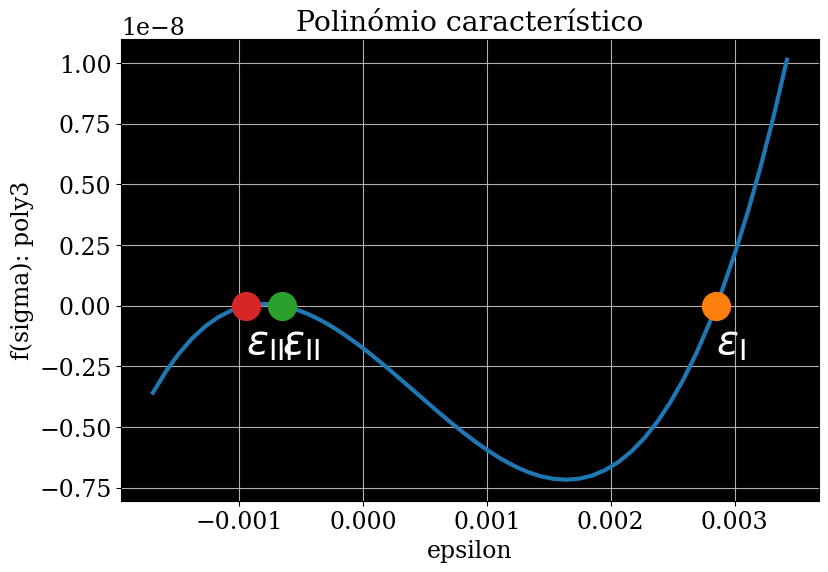

In [23]:
print('\n Calculo dos invariantes pela matriz das deformações: ............................')
print(' - valores próprios = deformações principais -')

J1 = np.trace(md0)
print(f'1º Invariante, J1 : {J1:.5e}')

J2 = 0.5*(np.trace(md0)**2 -np.trace(np.dot(md0,md0)))
print(f'2º Invariante, I2 : {J2:.5e}')

J3 = np.linalg.det(md0)
print(f'3º Invariante, I3 : {J3:.5e}')

print('\n Resolucao Numerica - Numpy : ............................')
valpropriosN = np.roots([1,-J1,J2,-J3])
valpropriosN = -np.sort(-valpropriosN)
print('Roots = ',valpropriosN)

eI = valpropriosN[0]
print(f'\n  Tensão principal eI : {eI*1e6:.3f} micro-def')
eII = valpropriosN[1]
print(f' Tensão principal eII : {eII*1e6:.3f} micro-def')
eIII = valpropriosN[2]
print(f'Tensão principal eIII : {eIII*1e6:.3f} micro-def')

srange = np.linspace(eIII*1.8,eI*1.2,50)
def polycaract(e):
    return e**3 - J1*e**2 + J2*e - J3

font = {'size' : 17}
plt.rc('font', **font)
plt.rcParams['axes.facecolor']='black'
plt.figure(figsize=(9,6))
plt.plot(srange,polycaract(srange),linewidth=3)
for i in valpropriosN:
     plt.plot(i,polycaract(i),'o',markersize=20)
plt.title('Polinómio característico')
plt.ylabel('f(sigma): poly3')
plt.xlabel('epsilon')
sleg = ('I','II','III')
j = 0
for i in (eI,eII,eIII):
    plt.text(i,-.2e-8,'$\epsilon_\mathrm{'+sleg[j]+'}$',color='white',
             fontfamily='monospace',fontsize='xx-large')
    j+=1
plt.grid('on')
plt.show()

As direções principais associadas a $\epsilon_\mathrm{I}$, $\epsilon_\mathrm{II}$ e $\epsilon_\mathrm{III}$ são obtidas substituindo $\epsilon_i~(i = 1, 2, 3)$ nas seguintes equações, resolvendo-as para $n_x$, $n_y$ e $n_z$:

\begin{equation*}
\begin{aligned}
(\varepsilon_{xx}-\epsilon_i) n_x + \varepsilon_{xy} n_y + \varepsilon_{xz} n_z &= 0 \\
\varepsilon_{xy} n_x + (\varepsilon_{yy}-\epsilon_i) n_y + \varepsilon_{yz} n_z &= 0 \\
\varepsilon_{xy} n_x + \varepsilon_{yz} n_y + (\varepsilon_{zz}-\epsilon_i) n_z &= 0 \\
n_x^2 + n_y^2 + n_z^2 &= 0
\end{aligned}
\end{equation*}

Se as três deformações principais forem distintas, $\epsilon_\mathrm{I} > \epsilon_\mathrm{II} > \epsilon_\mathrm{III}$, então os eixos $\vec{n}_\mathrm{I}, \vec{n}_\mathrm{II}, \vec{n}_\mathrm{III}$ são únicas e mutuamente perpendiculares.

Se, $\epsilon_\mathrm{I} = \epsilon_\mathrm{II} \ne \epsilon_\mathrm{III}$, então o eixo $\vec{n}_\mathrm{III}$ é único e todas as direções perpendicular a $\vec{n}_\mathrm{III}$ são uma direção principal associada a $\epsilon_\mathrm{I} = \epsilon_\mathrm{II}$. Se $\epsilon_\mathrm{I} = \epsilon_\mathrm{II} = \epsilon_\mathrm{III}$, então toda as direções são uma direção principal de deformação.

In [24]:
nx,ny,nz = symbols('nx ny nz')
def eq1(md,nx,ny,nz,vp): return (md[0,0] - vp)*nx + md[0,1]*ny + md[0,2]*nz
def eq2(md,nx,ny,nz,vp): return md[1,0]*nx + (md[1,1] - vp)*ny + md[1,2]*nz
def eq3(md,nx,ny,nz,vp): return md[2,0]*nx + md[2,1]*ny + (md[2,2] - vp)*nz
def eq4(nx,ny,nz): return nx**2 + ny**2 + nz**2 - 1

def versor(e1,e2,e3): return np.array([e1,e2,e3])

def VP1(md0,eI,i):
    # 1 valor proprio -------------------
    print('\nVetor próprio associado a eI = ','{:.4e}'.format(eI),'.............................')
    print('\n(i) Sistema de equações:')
    E1 = eq1(md0,nx,ny,nz,eI); print(E1,' = 0')
    E2 = eq2(md0,nx,ny,nz,eI); print(E2,' = 0')
    E3 = eq3(md0,nx,ny,nz,eI); print(E3,' = 0')
    E4 = eq4(nx,ny,nz); print(E4,' = 0')
    VetProp1 = solve([E1,E3,E4], [nx,ny,nz], dict=True)
    l1 = float(VetProp1[i][nx])
    m1 = float(VetProp1[i][ny])
    n1 = float(VetProp1[i][nz])
    print('\n (ii) vec{nI} = (','{:.3f}'.format(l1),') e1 + (','{:.3f}'.format(m1),') e2 + (','{:.3f}'.format(n1),') e3')
    return versor(l1,m1,n1)

def VP2(md0,eII,i):
    # 2 valor proprio -------------------
    print('\nVetor próprio associado a eII = ','{:.4e}'.format(eII),' .............................')
    print('\n(i) Sistema de equações:')
    E1 = eq1(md0,nx,ny,nz,eII); print(E1,' = 0')
    E2 = eq2(md0,nx,ny,nz,eII); print(E2,' = 0')
    E3 = eq3(md0,nx,ny,nz,eII); print(E3,' = 0')
    E4 = eq4(nx,ny,nz); print(E4,' = 0')
    VetProp2 = solve([E1,E3,E4], [nx,ny,nz], dict=True)
    l2 = float(VetProp2[i][nx])
    m2 = float(VetProp2[i][ny])
    n2 = float(VetProp2[i][nz])
    print('\n (ii) vec{nII} = (','{:.3f}'.format(l2),') e1 + (','{:.3f}'.format(m2),') e2 + (','{:.3f}'.format(n2),') e3')
    return versor(l2,m2,n2)

def  VP3(md0,eIII,i):
    # 3 valor proprio -------------------
    print('\nVetor próprio associado a eIII = ','{:.4e}'.format(eIII),' .............................')
    print('\n(i) Sistema de equações:')
    E1 = eq1(md0,nx,ny,nz,eIII); print(E1,' = 0')
    E2 = eq2(md0,nx,ny,nz,eIII); print(E2,' = 0')
    E3 = eq3(md0,nx,ny,nz,eIII); print(E3,' = 0')
    E4 = eq4(nx,ny,nz); print(E4,' = 0')
    VetProp3 = solve([E1,E2,E4], [nx,ny,nz], dict=True)
    l3 = float(VetProp3[i][nx])
    m3 = float(VetProp3[i][ny])
    n3 = float(VetProp3[i][nz])
    print('\n (iii) vec{nIII} = (','{:.3f}'.format(l3),') e1 + (','{:.3f}'.format(m3),') e2 + (','{:.3f}'.format(n3),') e3')
    return versor(l3,m3,n3)

nI = VP1(md0,eI,1)


Vetor próprio associado a eI =  2.8520e-03 .............................

(i) Sistema de equações:
-0.00082345363881051*nx + 0.00148571428571429*ny  = 0
0.00148571428571429*nx - 0.00268059649595337*ny  = 0
-0.00379488221023908*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

 (ii) vec{nI} = ( 0.875 ) e1 + ( 0.485 ) e2 + ( 0.000 ) e3


In [25]:
nII = VP2(md0,eII,0)


Vetor próprio associado a eII =  -6.5203e-04  .............................

(i) Sistema de equações:
0.00268059649595337*nx + 0.00148571428571429*ny  = 0
0.00148571428571429*nx + 0.000823453638810513*ny  = 0
-0.000290832075475201*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

 (ii) vec{nII} = ( -0.485 ) e1 + ( 0.875 ) e2 + ( 0.000 ) e3


In [26]:
nIII = VP3(md0,eIII,1)


Vetor próprio associado a eIII =  -9.4286e-04  .............................

(i) Sistema de equações:
0.00297142857142857*nx + 0.00148571428571429*ny  = 0
0.00148571428571429*nx + 0.00111428571428571*ny  = 0
-1.0842021724855e-18*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

 (iii) vec{nIII} = ( 0.000 ) e1 + ( 0.000 ) e2 + ( 1.000 ) e3


In [27]:
print('\n Versores principais: verificação')
print(f'dot(vpk,vpk) = {np.dot(nI,nI):.1f} | {np.dot(nII,nII):.1f} | {np.dot(nIII,nIII):.1f}')
print(f'dot(vpi,vpj) = {np.abs(np.dot(nI,nII)):.1f} | {np.dot(nII,nIII)} | {np.abs(np.dot(nI,nIII)):.1f}')

np.set_printoptions(formatter={'float': '{: 0.3f}'.format})
mT0P = np.concatenate((nI, nII, nIII))
mT0P = mT0P.reshape(3,3)
print('\n [T] = \n', mT0P)
print(f'\n det(T) = {np.linalg.det(mT0P):.2f}')

print('\n  Ângulos : S0 - SP  ººººººººººººººººººººººººººººº')
print(' ang (   nI = x* ; x0,y0,z0 ) = ',np.rad2deg(np.arccos(nI)),' (Deg)')
print(' ang (  nII = y* ; x0,y0,z0 ) = ',np.rad2deg(np.arccos(nII)),' (Deg)')
print(' ang ( nIII = z* ; x0,y0,z0 ) = ',np.rad2deg(np.arccos(nIII)),' (Deg)')

print('\nverificacao: .............. ')
np.set_printoptions(formatter={'float': '{: 0.1f}'.format})
epsPs0 = np.dot(mT0P,np.dot(md0,np.transpose(mT0P)))
print('Matriz deformação principal = \n',epsPs0*1e6,' micro-def')


 Versores principais: verificação
dot(vpk,vpk) = 1.0 | 1.0 | 1.0
dot(vpi,vpj) = 0.0 | 0.0 | 0.0

 [T] = 
 [[ 0.875  0.485  0.000]
 [-0.485  0.875  0.000]
 [ 0.000  0.000  1.000]]

 det(T) = 1.00

  Ângulos : S0 - SP  ººººººººººººººººººººººººººººº
 ang (   nI = x* ; x0,y0,z0 ) =  [ 28.997  61.003  90.000]  (Deg)
 ang (  nII = y* ; x0,y0,z0 ) =  [ 118.997  28.997  90.000]  (Deg)
 ang ( nIII = z* ; x0,y0,z0 ) =  [ 90.000  90.000  0.000]  (Deg)

verificacao: .............. 
Matriz deformação principal = 
 [[ 2852.0 -0.0  0.0]
 [-0.0 -652.0  0.0]
 [ 0.0  0.0 -942.9]]  micro-def


A deformação de corte ou dirtorção máxima:

\begin{equation*}
\gamma_\mathrm{max} = 2 \varepsilon_\mathrm{max}
= | \varepsilon_\mathrm{I} - \varepsilon_\mathrm{III} |
\quad\mathrm{[radians]}
\end{equation*}

In [28]:
gmax = np.abs(eI-eIII)
print('Deformação de corte máxima = ','{:.3f}'.format(gmax*1e6),' micro-rad')

Deformação de corte máxima =  3794.882  micro-rad


###### Análise gráfica

Analisando o estado de deformação no plano $x-y$, é possível demostar que as deformações principais vêm dadas por:

\begin{equation*}
\varepsilon_\mathrm{I,II} = \frac{\varepsilon_{xx}+\varepsilon_{yy}}{2} \pm
\left[ \left( \frac{\varepsilon_{xx}-\varepsilon_{yy}}{2} \right)^2 +
\left( \frac{\gamma_{xy}}{2} \right)^2 \right]^{1/2}
\end{equation*}

De notar que $\varepsilon_{zz} \equiv \varepsilon_\mathrm{III} = 0$ também é uma deformação principal e a direção dos eixos dos $zz$ uma direção principal de deformação.

Os eixos principais de deformação estão rodados de um ângulo $\phi$ e $\phi+90^\circ$ em relação ao eixo dos $xx$, definido por:

\begin{equation*}
\tan2\phi = \frac{\gamma_{xy}}{\varepsilon_{xx}-\varepsilon_{yy}}
\end{equation*}

In [29]:
def epsP(exx,eyy,gxy):
    eI =  (exx + eyy)/2 + np.sqrt( ((exx - eyy)/2)**2 + (gxy/2)**2 )
    eII =  (exx + eyy)/2 - np.sqrt( ((exx - eyy)/2)**2 + (gxy/2)**2 )
    return eI, eII

def angP(exx,eyy,gxy):
    return np.arctan(gxy/(exx-eyy))

epsI, epsII = epsP(exxP,eyyP,2*exyP)
print('Deformação principal eI = ','{:.3f}'.format(epsI*1e6),' micro-def')
print('Deformação principal eII = ','{:.3f}'.format(epsII*1e6),' micro-def')

aP1 = angP(exxP,eyyP,2*exyP)
aP2 = aP1 + np.pi/2
print('Ângulo principal 1 (espaço de Mohr) = ','{:.3f}'.format(np.rad2deg(aP1)),' Deg')
print('Ângulo principal 2 (espaço de Mohr) = ','{:.3f}'.format(np.rad2deg(aP2)),' Deg')

aPI = aP1/2
aPII = aP2/2
print('Ângulo principal I (espaço físico) = ','{:.3f}'.format(np.rad2deg(aPI)),' Deg')
print('Ângulo principal II (espaço físico) = ','{:.3f}'.format(np.rad2deg(aPII)),' Deg')

def gammax1y1(eXX,eYY,gXY,t): return -(eXX - eYY)*np.sin(2*t) + gXY*np.cos(2*t)
def angShearMax(exx,eyy,gxy): return np.arctan( -(exx-eyy)/gxy )

corteAngP1 = angShearMax(exxP,eyyP,2*exyP)/2
corteAngP2 = corteAngP1 + np.pi/2
print('Orientação do angular principal (máximom\\ínimo) : ','{:.2f}'.format(np.rad2deg(corteAngP1)))
print('Orientação do angular principal (máximo\\mínimo) : ','{:.2f}'.format(np.rad2deg(corteAngP2)))

Deformação principal eI =  2852.025  micro-def
Deformação principal eII =  -652.025  micro-def
Ângulo principal 1 (espaço de Mohr) =  57.995  Deg
Ângulo principal 2 (espaço de Mohr) =  147.995  Deg
Ângulo principal I (espaço físico) =  28.997  Deg
Ângulo principal II (espaço físico) =  73.997  Deg
Orientação do angular principal (máximom\ínimo) :  -16.00
Orientação do angular principal (máximo\mínimo) :  74.00


Extensões principais: -------------------------------------------
Ângulo principal (Deg) = 28.9973
            Extensão I = 2.85203e-03
           Extensão II = -6.52025e-04
   Distorção de corte  = 0.0
Disturções principais: -------------------------------------------
Ângulo principal (Deg) = 73.9973
            Extensão I = 1.10000e-03
           Extensão II = 1.10000e-03
   Distorção principal = -3.50405e-03


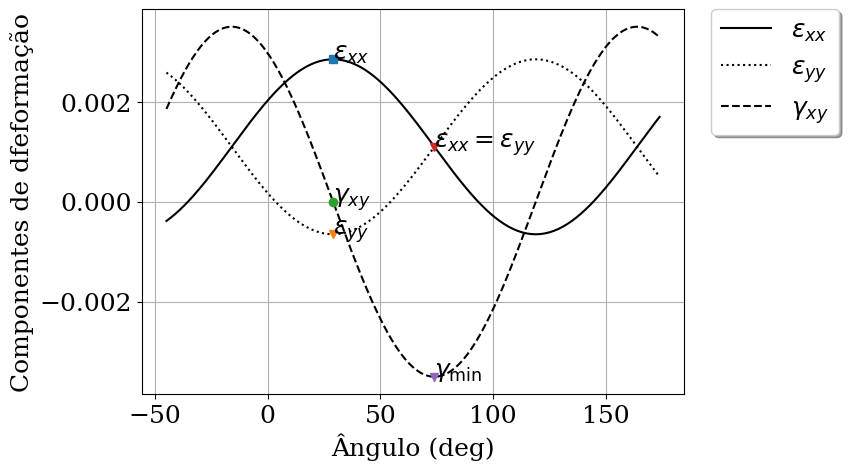

In [30]:
def epsx1(eXX,eYY,gXY,t): return eXX*np.cos(t)**2 + eYY*np.sin(t)**2 + gXY*np.sin(t)*np.cos(t)
def epsy1(eXX,eYY,gXY,t): return eXX*np.sin(t)**2 + eYY*np.cos(t)**2 - gXY*np.sin(t)*np.cos(t)
def gammax1y1(eXX,eYY,gXY,t): return -(eXX - eYY)*np.sin(2*t) + gXY*np.cos(2*t)

tang = np.arange(-45,175,1)
# extensões normais
extXang = epsx1(exxP,eyyP,2*exyP,np.deg2rad(tang))
extYang = epsy1(exxP,eyyP,2*exyP,np.deg2rad(tang))
# distorção angular
distang = gammax1y1(exxP,eyyP,2*exyP,np.deg2rad(tang))

print('Extensões principais: -------------------------------------------')
epsI = epsx1(exxP,eyyP,2*exyP,aPI)
epsII = epsy1(exxP,eyyP,2*exyP,aPI)
gammaP = gammax1y1(exxP,eyyP,2*exyP,aPI)
print('Ângulo principal (Deg) =','{:.4f}'.format(np.rad2deg(aPI)))
print('            Extensão I =','{:.5e}'.format(epsI))
print('           Extensão II =','{:.5e}'.format(epsII))
print('   Distorção de corte  =','{:.1f}'.format(gammaP))

print('Disturções principais: -------------------------------------------')
epsx1ShearMin = epsx1(exxP,eyyP,2*exyP,corteAngP2)
epsy1ShearMin = epsy1(exxP,eyyP,2*exyP,corteAngP2)
corteMin = gammax1y1(exxP,eyyP,2*exyP,corteAngP2)
print('Ângulo principal (Deg) =','{:.4f}'.format(np.rad2deg(corteAngP2)))
print('            Extensão I =','{:.5e}'.format(epsx1ShearMin))
print('           Extensão II =','{:.5e}'.format(np.abs(epsy1ShearMin)))
print('   Distorção principal =','{:.5e}'.format(corteMin))

# use LaTeX fonts in the plot
#plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=18)
plt.rcParams['axes.facecolor']='white'

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(tang, extXang, 'k-', label=r'$\varepsilon_{xx}$')
ax.plot(tang, extYang, 'k:', label=r'$\varepsilon_{yy}$')
ax.plot(tang, distang, 'k--', label=r'$\gamma_{xy}$')

ax.plot(np.rad2deg(aPI), epsI, 's')
ax.text(np.rad2deg(aPI), epsI,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aPI), epsII, 'v')
ax.text(np.rad2deg(aPI), epsII,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aPI), gammaP, 'o')
ax.text(np.rad2deg(aPI), gammaP,r'$\gamma_{xy}$')

ax.plot(np.rad2deg(corteAngP2), epsx1ShearMin, 'v')
ax.text(np.rad2deg(corteAngP2), epsx1ShearMin,r'$\varepsilon_{xx}=\varepsilon_{yy}$')
#ax.plot(np.rad2deg(corteAngP2), epsy1ShearMin, 'v')
#ax.text(np.rad2deg(corteAngP2), epsy1ShearMin,r'yy')
ax.plot(np.rad2deg(corteAngP2), corteMin, 'v')
ax.text(np.rad2deg(corteAngP2), corteMin,r'$\gamma_{\mathrm{min}}$')

ax.set(xlabel='Ângulo (deg)', ylabel='Componentes de dfeformação')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.grid()
plt.show()


PLANO x-y:
  Deformação normal mínima:  -6.52000e-04
  Deformação normal máxima:  2.85200e-03
  Deformação normal média :  1.10000e-03
Deformação de corte mínima:  -1.75200e-03
Deformação de corte máxima:  1.75200e-03
Ponto A ( 2.02857e-03 , -1.48571e-03 )
Ponto B ( 1.71429e-04 , 1.48571e-03 )


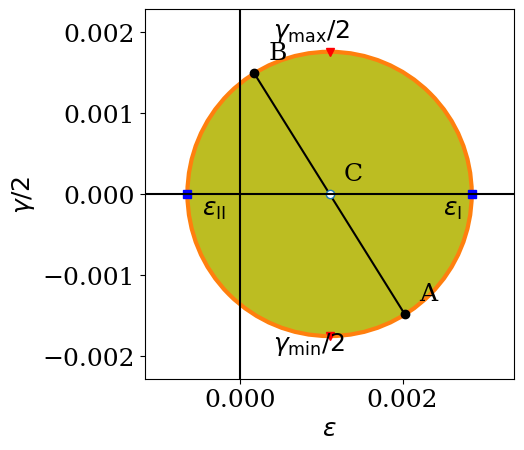

In [31]:
def mohr(E):
    E11 = E[0][0]
    E12 = E[0][1]
    E22 = E[1][1]
    center = [(E11 + E22)/2.0, 0.0]
    radius = np.sqrt((E11 - E22)**2/4.0 + E12**2)
    Emin = center[0] - radius
    Emax = center[0] + radius

    print("  Deformação normal mínima: ", '{:.5e}'.format(np.round(Emin,6)))
    print("  Deformação normal máxima: ", '{:.5e}'.format(np.round(Emax, 6)))
    print("  Deformação normal média : ", '{:.5e}'.format(np.round(center[0], 6)))
    print("Deformação de corte mínima: ", '{:.5e}'.format(np.round(-radius, 6)))
    print("Deformação de corte máxima: ", '{:.5e}'.format(np.round(radius, 6)))

    print('Ponto A (','{:.5e}'.format(E11),',','{:.5e}'.format(-E12),')')
    print('Ponto B (','{:.5e}'.format(E22),',','{:.5e}'.format(E12),')')

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Emin - .3*radius, Emax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([E11, E22], [-E12, E12], 'ko')
    plt.plot([E11, E22], [-E12, E12], 'k')
    plt.plot(Emin, 0, 'bs')
    plt.plot(Emax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(E11 + desv, -E12 + desv , 'A')
    plt.text(E22 + desv, E12 + desv, 'B')
    plt.text(Emin + .1*radius, -0.15*radius, r'$\varepsilon_\mathrm{II}$')
    plt.text(Emax - .2*radius, -0.15*radius, r'$\varepsilon_\mathrm{I}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\gamma_\mathrm{max}/2$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\gamma_\mathrm{min}/2$')
    plt.xlabel(r"$\varepsilon$", size=18)
    plt.ylabel(r"$\gamma/2$", size=18)
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

print('\n================================')
print('PLANO x-y:')
print('================================')
E1 = np.array([[exxP, exyP],[exyP, eyyP]])
mohr(E1)

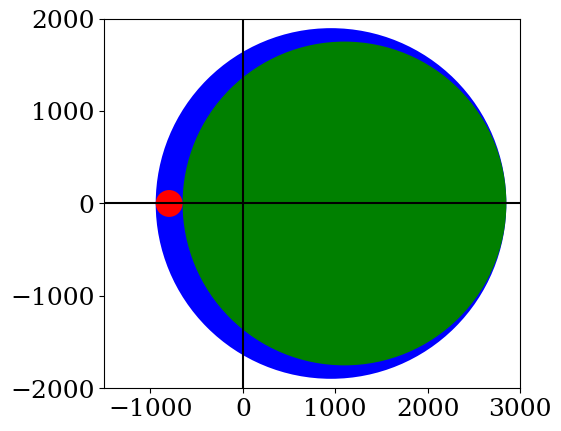

In [32]:
def circleradius(E):
    E11 = E[0,0]; E12 = E[0,1]; E22 = E[1,1]
    center = [(E11 + E22)/2.0, 0.0]
    radius = np.sqrt((E11 - E22)**2/4.0 + E12**2)
    return center, radius

limits = np.array([[-1500,3000],[-2000,2000]])

E11 = eI*1e6; E22 = eIII*1e6; E12 = 0
E = np.array([[E11, E12],[E12, E22]])
center1, radius1  = circleradius(E)

E11 = eI*1e6; E22 = eII*1e6; E12 = 0
E = np.array([[E11, E12],[E12, E22]])
center2, radius2  = circleradius(E)

E11 = eII*1e6; E22 = eIII*1e6; E12 = 0
E = np.array([[E11, E12],[E12, E22]])
center3, radius3  = circleradius(E)

circ1 = plt.Circle((center1[0],0), radius1, facecolor='b')
circ2 = plt.Circle((center2[0],0), radius2, facecolor='g')
circ3 = plt.Circle((center3[0],0), radius3, facecolor='r')

plt.axis('image'); ax = plt.gca()

plt.gcf().gca().add_artist(circ1)
plt.gcf().gca().add_artist(circ2)
plt.gcf().gca().add_artist(circ3)

#plt.xlabel(r'$\sigma$', size=18)
#plt.ylabel(r'$\tau$', size=18)

#plt.text(1.05*eI, 0, r'$\sigma_\mathrm{I}$')
#plt.text(1.2*eII, 0, r'$\sigma_\mathrm{II}$')
#plt.text(-1.5*eIII, 0, r'$\sigma_\mathrm{III}$')

plt.xlim(limits[0,0],limits[0,1])
plt.ylim(limits[1,0],limits[1,1])

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.show()

#### d) Determine as componentes normal e tangencial da tensão no plano vertical que passa pela diagonal representada na figura.<a name="D"></a>

([enunciatum](#PIII76))

As componentes cartesianas do tensor das tensões num referencial $S_1$ (sistema de coordenadas definido pelos versores normal e tangencial à diagonal da placa) podem ser obtidos a partir da matriz do tensor das tensões no referencial $S_0(x,y,z)$ de acordo com a seguinte lei de transformação de um tensor de segunda ordem simétrico:

\begin{equation*}
[\sigma]_1 = [T_{01}] [\sigma]_0 [T_{01}]^T
\end{equation*}

em que a tensão normal é dada por: $\sigma_n = \sigma_{nn}$ e a tensão tangencial vem dada por: $\tau = \tau_{ns}$. Neste caso o versor exterior à faceta contida no plano vertical que passa pela diagonal representada na figura, é definido por uma rotação em torno do eixo comum dos $zz$ por um ângulo $\theta$ tal que:

\begin{equation*}
\begin{aligned}
\theta &= \arctan\frac{L_x}{L_y} \\
\vec{n} &= \cos\theta \, \vec{\imath} + \sin\theta \,\vec{\jmath}\\
\end{aligned}
\end{equation*}

In [33]:
thetad = np.arctan(Lx/Ly)
mTd = Q(thetad,3)
print('matriz de transformação Q01 :\n',mTd)
sigS1 = np.dot(np.dot(mTd,mt0),np.transpose(mTd))
print('tensor tensoes S1(n,s) :\n',sigS1)
print(f'tensão normal sig_nn = {sigS1[0,0]:3.3f} MPa')
print(f'tensão normal tau_ns = {sigS1[0,1]:3.3f} MPa')

matriz de transformação Q01 :
 [[ 0.9  0.4  0.0]
 [-0.4  0.9  0.0]
 [ 0.0  0.0  1.0]]
tensor tensoes S1(n,s) :
 [[ 202.0  20.8  0.0]
 [ 20.8  18.0  0.0]
 [ 0.0  0.0  0.0]]
tensão normal sig_nn = 202.012 MPa
tensão normal tau_ns = 20.828 MPa


A tensão normal e a tensão de corte podem ainda ser obtidos através das seguintes expressões:

\begin{equation*}
\begin{aligned}
\sigma_\mathrm{n} &= \frac{1}{2}(\sigma_{xx} + \sigma_{yy}) +
\frac{1}{2}(\sigma_{xx} - \sigma_{yy})\cos2\theta +
\tau_{xy}\sin2\theta \\
\tau_\mathrm{n} &= -\frac{1}{2}(\sigma_{xx} - \sigma_{yy})\sin2\theta +
\tau_{xy}\cos2\theta \\
\end{aligned}
\end{equation*}

In [34]:
print('----------------------')
print('txy = 80 MPa')
print('----------------------')
sigN = 0.5*(sxxP+syyP) + 0.5*(sxxP-syyP)*np.cos(2*thetad) + sxyP*np.sin(2*thetad)
print(' sigN = ','{:.3f}'.format(sigN),' MPa')
sigT = -0.5*(sxxP-syyP)*np.sin(2*thetad) + sxyP*np.cos(2*thetad)
print(' sigT = ','{:.3f}'.format(sigT),' MPa')


----------------------
txy = 80 MPa
----------------------
 sigN =  202.012  MPa
 sigT =  20.828  MPa


Por outro lado a tensão normal e tensão tangential do vetor tensão no referencial local da faceta podem se determinados por:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au07/Au07_P006_i4.jpg"
width="400" height="180">

In [35]:
print('Pelo produto interno = vetor tensão. versor normal exterior à faceta:')

vernor = np.array([np.cos(thetad), np.cos(np.pi/2-thetad), 0])
print('versor n : ',vernor)
vect  = np.dot(mt0,vernor)
print('vet.  tensão: ',vect)
tennormal = np.dot(vect,vernor)
print('tens. normal : ','{:.3f}'.format(tennormal),' MPa')
tencorte = np.sqrt( np.dot(vect,vect) - tennormal**2)
print('tens. corte : ','{:.3f}'.format(tencorte),' MPa')

Pelo produto interno = vetor tensão. versor normal exterior à faceta:
versor n :  [ 0.9  0.4  0.0]
vet.  tensão:  [ 178.5  96.9  0.0]
tens. normal :  202.012  MPa
tens. corte :  20.828  MPa


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
